In [1]:
#data format library
import h5py

#numpy
import numpy as np
import pandas as pd
import numpy.ma as ma
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
matplotlib.rcParams['pdf.fonttype'] = 42
# %matplotlib notebook
import sys
sys.path.append('./utils/')
import matplotlib.colors as pltcolors
import os
import copy
import partitioning_methods as cl
import operator_calculations as op_calc
import diffusion_maps as dmaps
import coarse_graining as cgm
import delay_embedding as embed
import simulation_functions as sim_funcs
import stats
import time

from scipy.sparse import csr_matrix
import deeptime.markov.tools.estimation as msm_estimation
import scipy.sparse as sp
from scipy.interpolate import CubicSpline

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
Fig_path = '/flash/StephensU/Gautam/Figures/Comparing_MultiScale_Dynamics/Fig_3wellpot/'

In [3]:
final_dt = 0.05

out_path = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/3well_pchip/'
f = h5py.File(out_path+'L_approx_metaData.h5','r')
tau_x = np.array(f['tau_x'])[0]
labels_phen = np.array(f['labels_phen'])
phens = np.array(f['phens'])
Tx = np.array(f['Tx'])[0]
print(tau_x)
f.close()

1.0


In [2]:
Texp_range = np.array(np.logspace(2,4.0,11),dtype=int)
Texp_range = np.hstack([[10,17,31,56],Texp_range])
print(Texp_range)

[   10    17    31    56   100   158   251   398   630  1000  1584  2511
  3981  6309 10000]


In [12]:
from scipy.interpolate import PchipInterpolator
def get_potential(phen,der=False):
    N = 1000
    x_min, x_max = -2,2
    xsample = np.linspace(x_min, x_max, N)
    n_barriers = 2
    domain = [-2,2]
    max_spacing = (domain[1]-domain[0])/(n_barriers+1)
    n_minima = n_barriers+1
    min_locs = np.array([domain[0]+max_spacing/2 + k*max_spacing for k in range(n_minima)])
    max_locs = np.array([domain[0] + k*max_spacing for k in range(n_barriers+2)])
    
    max_heights = np.array([4,0,-0.75,4])

    mins = np.array(phen)
    min_heights = np.array(mins)
    x_all = np.hstack([max_locs,min_locs])
    y_all = np.hstack([max_heights,min_heights])
    sort = np.argsort(x_all)
    x_all = x_all[sort]
    y_all = y_all[sort]
    V = PchipInterpolator(x_all,y_all)

    if der == True:
        return V.derivative()
    else:
        return V

0
1
2
3


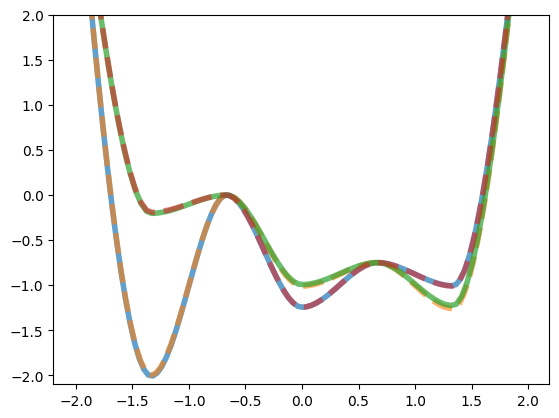

In [13]:
x_min, x_max = -2,2
xsample = np.linspace(x_min, x_max, 1000)
xsel = xsample
markers = ['o','d','*','^']
for i in np.unique(labels_phen):
    idx = np.where(labels_phen == i)[0]
    i = int(i)
    print(i)
    if i %2 == 0:
        plt.plot(xsel[::10+i],get_potential(phens[idx[5]])(xsel)[::10+i],lw=4,color='C{}'.format(int(i)), alpha=0.7)
    else:
        plt.plot(xsel[::10+i],get_potential(phens[idx[5]])(xsel)[::10+i],lw=4,ls='--',color='C{}'.format(int(i)), alpha=0.6)
plt.ylim(-2.1,2.)
# plt.xlim(-1.1,1.1)
# plt.xlim(-1.2,1.2)
# plt.savefig(Fig_path+'3_well_pot_phens.pdf')
plt.show()

In [14]:
path_to_filtered_data = '/flash/StephensU/Gautam/HMD/Results/3well_pchip/T1000/'
f = h5py.File(path_to_filtered_data + 'trajs.h5','r')
print(f.keys())
trajs = ma.array(f['trajs'],dtype=float)
f.close()

<KeysViewHDF5 ['MetaData', 'trajs']>


0


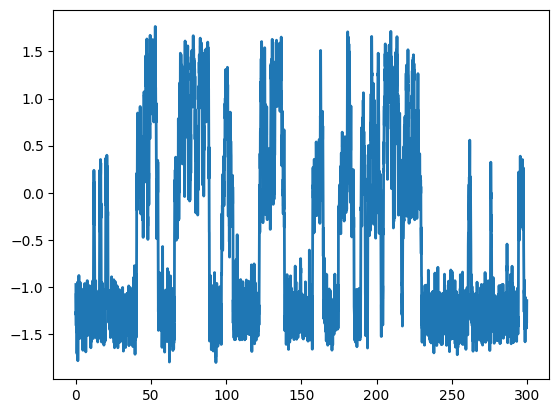

1


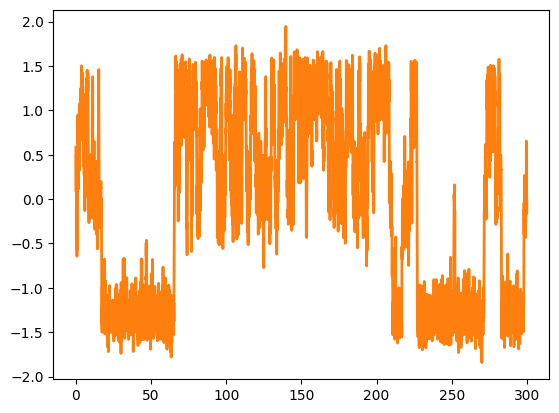

2


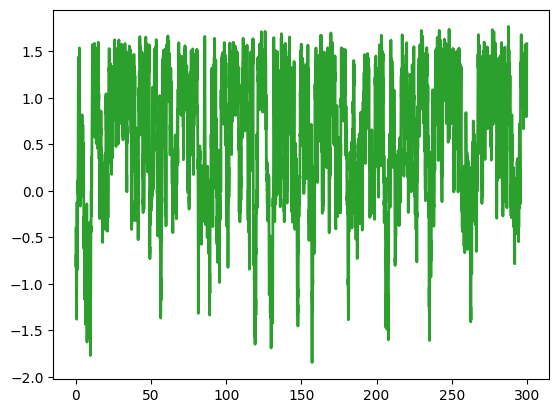

3


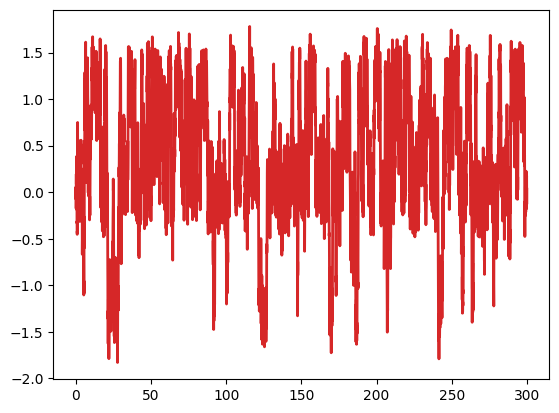

In [15]:
for i in np.unique(labels_phen):
    idx = np.where(labels_phen == i)[0]
    i = int(i)
    print(i)
    plt.plot(np.arange(6000)*final_dt,trajs[idx[5]][:6000],lw=2,color='C{}'.format(int(i)))
    # plt.ylim(-1.1,1.1)
    # plt.axis('off')
    # plt.savefig(Fig_path+'3_well_pot_exsims{}.pdf'.format(i))
    # plt.savefig('/Users/gautam.sridhar/Documents/Post_ZENITH/Comparing_MultiScale_Dynamics/Figures/3_well_pot_exsims{}.pdf'.format(i))
    plt.show()

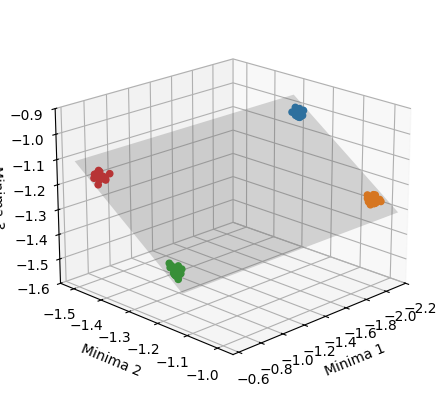

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def set_axes_equal(ax):
    """
    Make axes of 3D plot have equal scale so that spheres appear as spheres,
    cubes as cubes, etc.

    Input
      ax: a matplotlib axis, e.g., as output from plt.gca().
    """

    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    # The plot bounding box is a sphere in the sense of the infinity
    # norm, hence I call half the max range the plot radius.
    plot_radius = 0.5*max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

m,b=np.polyfit(phens[:,2],phens[:,1],1)
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(projection='3d')
ax.view_init(20,45)

# Define the range for x and y
x_ = np.linspace(-2.1,-0.12, 100)
y_ = np.linspace(-.95, -1.3, 100)

# Create a meshgrid for x and y
X_, Y_ = np.meshgrid(x_, y_)

# Plot the plane
ax.plot_surface(X_, Y_, m*Y_+b, alpha=.25, color='gray',rstride=100,cstride=100)



for kl in np.unique(labels_phen):
    ax.scatter(phens[labels_phen==kl,0],phens[labels_phen==kl,1],phens[labels_phen==kl,2],alpha=1,zorder=10)

# Set labels and title
ax.set_xlim(-2.2,-0.55)
ax.set_zlim(-1.6,-0.9)
ax.set_ylim(-1.55,-0.95)
ax.set_xlabel('Minima 1')
ax.set_ylabel('Minima 2')
ax.set_zlabel('Minima 3')
# set_axes_equal(ax)
# plt.axis('equal')
# ax.set_box_aspect((np.ptp(phens[:,0]),np.ptp(phens[:,1]), np.ptp(phens[:,2])))  # xy aspect ratio is 1:1, but stretches z axis
# ax.set_box_aspect((2,1,1))
# plt.savefig(Fig_path + '3_well_phenospace.pdf')
plt.show()

In [5]:
path_to_filtered_data = '/flash/StephensU/Gautam/Multiscale_phenotypic_variation/Results/3well_pchip/T1000/'
f = h5py.File(path_to_filtered_data + 'microstate_labels.h5','r')
print(f.keys())
lengths_all = np.array(f['MetaData/lengths_data'], dtype=int)
labels_recs = ma.array(f['microstate_labels'],dtype=int)
f.close()

<KeysViewHDF5 ['MetaData', 'microstate_labels']>


In [6]:
f = h5py.File(path_to_filtered_data+'distances_combined.h5','r')
Dc_q_data = np.array(f['Dc_q_data'],dtype=float)
Dc_q_eps = np.array(f['Dc_q_eps'],dtype=float)
q_range = np.array(f['q_range'],dtype=float)
f.close()

In [7]:
# D_eps_arr = np.stack(D_eps_list,axis=0)
D_arr = Dc_q_data
Eps_arr = Dc_q_eps

In [8]:
D_ratio = Dc_q_data/(Dc_q_eps)-1
for i in range(len(D_ratio)):
    np.fill_diagonal(D_ratio[i],0)
# D_ratio = Dc_q_data-Dc_q_reg_eps

D_ratio[D_ratio<0]=0
D_int = np.trapz(D_ratio,q_range,axis=0)
np.fill_diagonal(D_int,0)

/scratch/ipykernel_3901835/2748439544.py:1: RuntimeWarning: invalid value encountered in divide
  D_ratio = Dc_q_data/(Dc_q_eps)-1


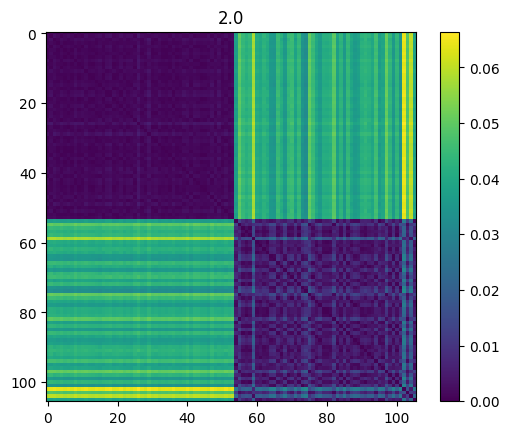

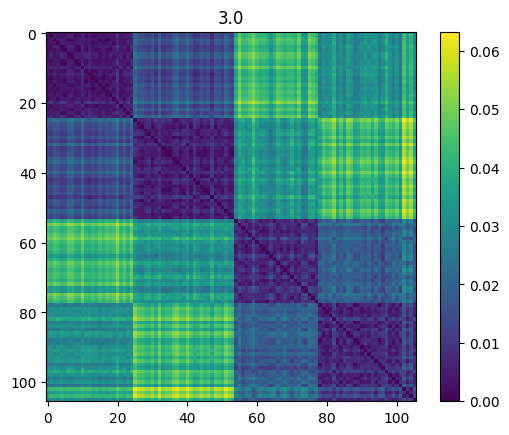

In [9]:
for i in range(2):
    plt.title(q_range[i])
    plt.imshow(Dc_q_data[i].data)
    plt.colorbar()
    # plt.savefig(Fig_path+'D_q_{}.pdf'.format(q_range[i]))
    plt.show()

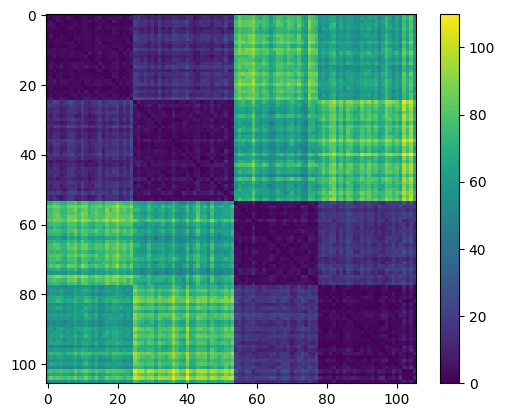

In [20]:
plt.imshow(D_int)
plt.colorbar()
# plt.savefig(Fig_path+'D_int.pdf')

/scratch/ipykernel_3821286/4070145603.py:39: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1.0)


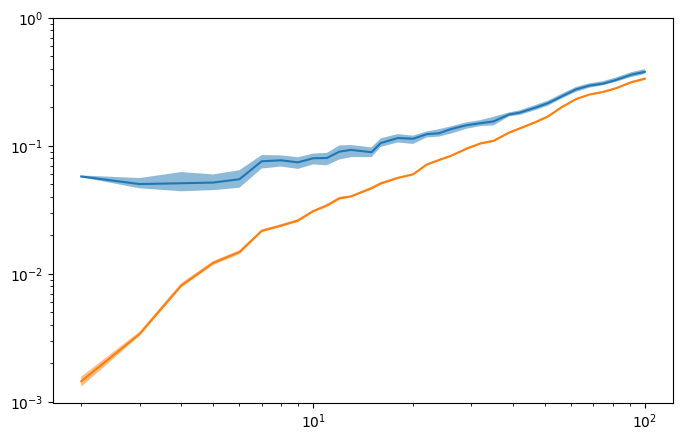

In [21]:
conds_to_comp = [[0],[2]]
cond_recs1 = []
cond_recs2 = []

cond_recs1.append(np.where(labels_phen == conds_to_comp[0])[0])
cond_recs1 = np.hstack(cond_recs1)


cond_recs2.append(np.where(labels_phen == conds_to_comp[1])[0])
cond_recs2 = np.hstack(cond_recs2)


D_here = Dc_q_data[:,cond_recs1,:][:,:,cond_recs2]
Eps_here = Dc_q_eps[:,cond_recs1,:][:,:,cond_recs2]


plt.figure(figsize=(8,5))
mean = D_here.max(axis=2).mean(axis=1)
# mean= np.median(Dc_q_data.max(axis=2),axis=1)
cil = np.percentile(D_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(D_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='data')
plt.fill_between(q_range,cil,ciu,alpha=.5)

mean = Eps_here.max(axis=2).mean(axis=1)
# mean = np.median(Dc_q_eps.max(axis=2),axis=1)
cil = np.percentile(Eps_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Eps_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='eps')
plt.fill_between(q_range,cil,ciu,alpha=.5)
# plt.axvline(20,c='k',ls='--')
# plt.axvline(3,c='k',ls='--')
# plt.axvline(12,c='k',ls='--')
# plt.axvline(91,c='k',ls='--')
plt.xscale('log')
plt.yscale('log')
# plt.xlabel('q')
# plt.ylabel('<D>')
plt.ylim(0,1.0)
# plt.savefig(Fig_path+'/dist_v_eps_cond1_cond2.pdf')
plt.show()

/scratch/ipykernel_3821286/2162631654.py:39: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,1.0)


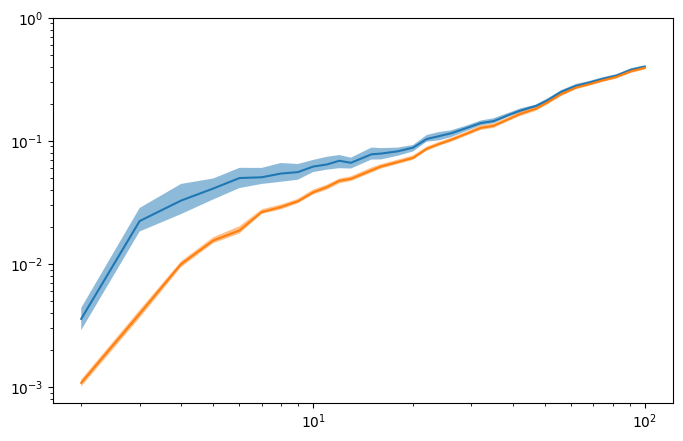

In [22]:
conds_to_comp = [[0],[1]]
cond_recs1 = []
cond_recs2 = []

cond_recs1.append(np.where(labels_phen == conds_to_comp[0])[0])
cond_recs1 = np.hstack(cond_recs1)


cond_recs2.append(np.where(labels_phen == conds_to_comp[1])[0])
cond_recs2 = np.hstack(cond_recs2)


D_here = Dc_q_data[:,cond_recs1,:][:,:,cond_recs2]
Eps_here = Dc_q_eps[:,cond_recs1,:][:,:,cond_recs2]


plt.figure(figsize=(8,5))
mean = D_here.max(axis=2).mean(axis=1)
# mean= np.median(Dc_q_data.max(axis=2),axis=1)
cil = np.percentile(D_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(D_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='data')
plt.fill_between(q_range,cil,ciu,alpha=.5)

mean = Eps_here.max(axis=2).mean(axis=1)
# mean = np.median(Dc_q_eps.max(axis=2),axis=1)
cil = np.percentile(Eps_here.max(axis=2),2.5,axis=1)
ciu =  np.percentile(Eps_here.max(axis=2),97.5,axis=1)
plt.plot(q_range,mean,label='eps')
plt.fill_between(q_range,cil,ciu,alpha=.5)
# plt.axvline(20,c='k',ls='--')
# plt.axvline(3,c='k',ls='--')
# plt.axvline(12,c='k',ls='--')
# plt.axvline(91,c='k',ls='--')
plt.xscale('log')
plt.yscale('log')
# plt.xlabel('q')
# plt.ylabel('<D>')
plt.ylim(0,1.0)
# plt.savefig(Fig_path+'/dist_v_eps_cond1_cond2.pdf')
plt.show()

In [11]:
from scipy.sparse.linalg import eigs
sorted_d = np.sort(D_int, axis=1)
k=55
M = dmaps.self_tuning_diffusion_tmat(D_int,sorted_d,k,1)

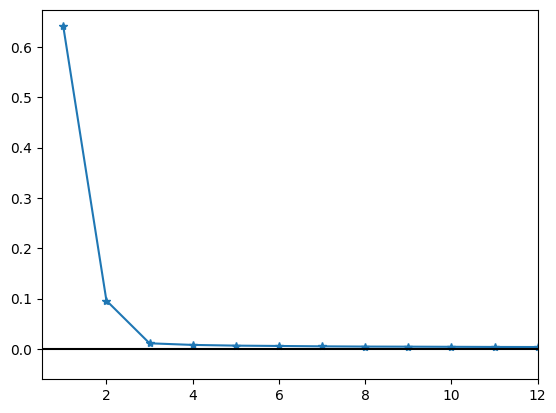

In [12]:
# P = np.trapz(1-kern_arr,cgs,axis=0)
from scipy.sparse.linalg import eigs
diff_eig, diff_ev = np.linalg.eig(M)
diff_inv_mes = op_calc.stationary_distribution(M)
sorted_indices = np.argsort(diff_eig.real)[::-1]
diff_eig = diff_eig[sorted_indices].real

diff_eigvecs = diff_ev / np.sqrt((diff_ev**2 * diff_inv_mes[:, None]).sum(axis=0))

# print(diff_eig)
# inv_measure = diff_eigvecs[:,0].real
diff_dists = diff_eig*(diff_eigvecs[:,sorted_indices].real)

plt.plot(np.arange(1,len(diff_eig)),diff_eig[1:],marker='*')
plt.axhline(0,c='k')
plt.xlim(0.5,12)
# large_eig.append(diff_eig[0])

# plt.axhline(ma.mean(max_eigs),c='k')
# cil = np.nanpercentile(max_eigs,2.5)
# ciu = np.nanpercentile(max_eigs,97.5)
# plt.axhspan(cil,ciu,color='k',alpha=.3)
# plt.savefig(Fig_path+ '/Diff_map_eigvals.pdf')
# plt.savefig('/Users/gautam.sridhar/Documents/Post_ZENITH/Comparing_MultiScale_Dynamics/Figures/Fig_3wellpot/Diff_map_eigvals.pdf')
plt.show()

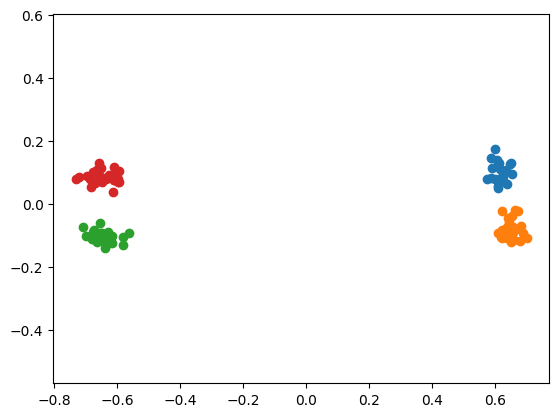

In [14]:
for ks in np.sort(np.unique(labels_phen)):
    plt.scatter(-1*diff_dists[labels_phen==ks,1],diff_dists[labels_phen==ks,2])
plt.axis('equal')
plt.savefig(Fig_path+'Diff_embedding.pdf')
# plt.savefig('/Users/gautam.sridhar/Documents/Post_ZENITH/Comparing_MultiScale_Dynamics/Figures/Fig_3wellpot/Diff_embedding.pdf')